In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your exported CSV (change path to your file)
df = pd.read_csv("Metric3_IdleFailCount_sheet - Form Responses 1 (1).csv")

# --- Rename scenes for readability ---
rename_map = {
    "Main": "Level 1",
    "MainForLevel2": "Level 2 (Normal Maze)",
    "Level2_DarkMaze": "Level 2 (Dark Maze)",
    "MainForLevel3": "Level 3"
}
df["sceneName"] = df["sceneName"].replace(rename_map)


# Convert timestamps and numerics
df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
num_cols = [
    "levelIndex", "attemptIndex", "idleThresholdSec",
    "idleDeathCountThisLevel", "timeSinceLevelStartSec", "submitOnNth"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Clean scene names for grouping
df["sceneName"] = df["sceneName"].fillna("Unknown").astype(str)
print(df.head())

            Timestamp  Column 1                        ts  \
0  11/9/2025 15:35:11       NaN 2025-11-09 23:59:59+00:00   
1  11/9/2025 15:44:09       NaN                       NaT   
2  11/9/2025 15:45:47       NaN                       NaT   
3  11/9/2025 15:47:01       NaN                       NaT   
4  11/9/2025 15:48:49       NaN                       NaT   

                              sessionId              sceneName  levelIndex  \
0                            dev-abc123                Level 1           1   
1  47AFAC0F-3472-5145-9E49-770C465AD7B8                Level 1          -1   
2  47AFAC0F-3472-5145-9E49-770C465AD7B8                Level 1          -1   
3  47AFAC0F-3472-5145-9E49-770C465AD7B8  Level 2 (Normal Maze)          -1   
4  47AFAC0F-3472-5145-9E49-770C465AD7B8    Level 2 (Dark Maze)          -1   

   attemptIndex  eventType  idleThresholdSec  idleDeathCountThisLevel  \
0             3  IdleDeath                 3                        1   
1            -1  I

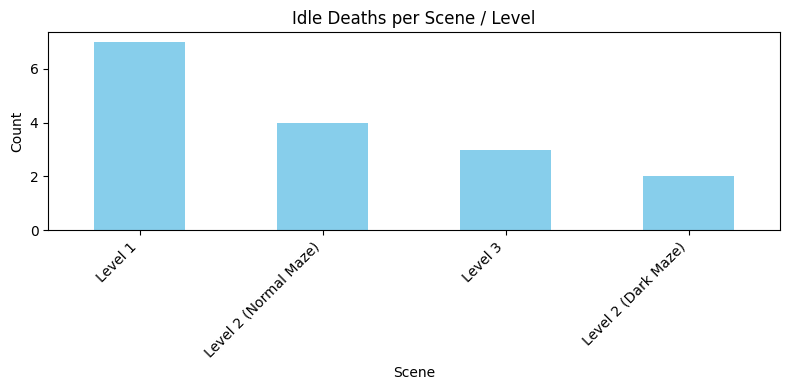

In [ ]:
scene_counts = df.groupby("sceneName").size().sort_values(ascending=False)
scene_counts.plot(kind="bar", color="skyblue", figsize=(8,4))
plt.title("Idle Deaths per Scene / Level")
plt.xlabel("Scene")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


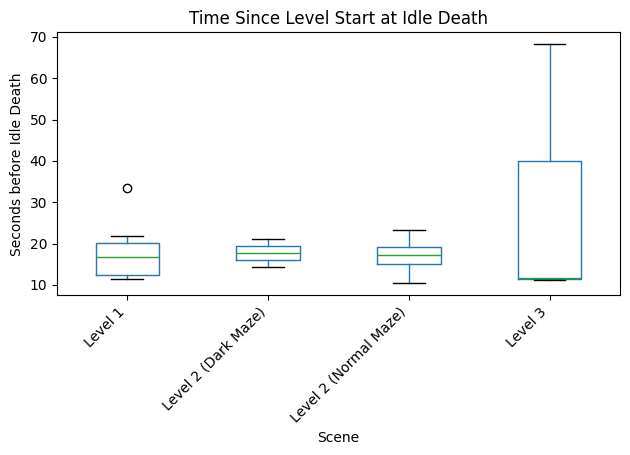

In [ ]:
df.boxplot(column="timeSinceLevelStartSec", by="sceneName", grid=False)
plt.title("Time Since Level Start at Idle Death")
plt.suptitle("")  # remove automatic extra title
plt.xlabel("Scene")
plt.ylabel("Seconds before Idle Death")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

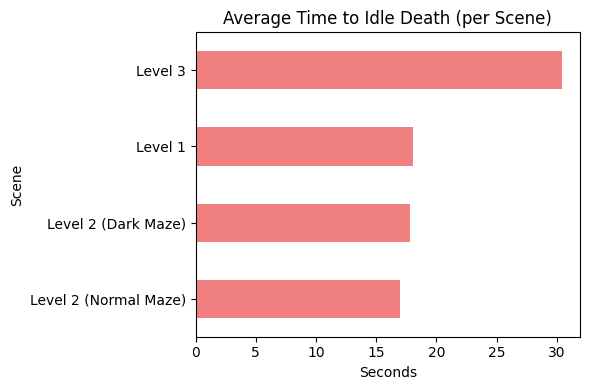

In [ ]:
avg_idle = df.groupby("sceneName")["timeSinceLevelStartSec"].mean().sort_values()
avg_idle.plot(kind="barh", color="lightcoral", figsize=(6,4))
plt.title("Average Time to Idle Death (per Scene)")
plt.xlabel("Seconds")
plt.ylabel("Scene")
plt.tight_layout()
plt.show()
